# Univariate Statistical Analysis

Objective:
To understand the distribution, variability, and behavior of each feature.

This forms the foundation for identifying anomalies, outliers, and financial irregularities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


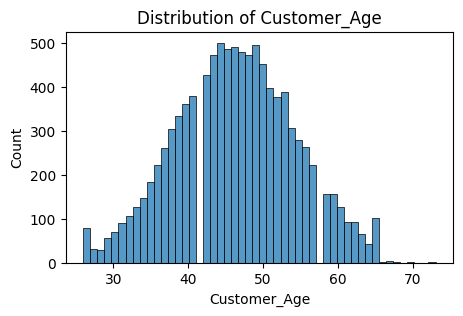

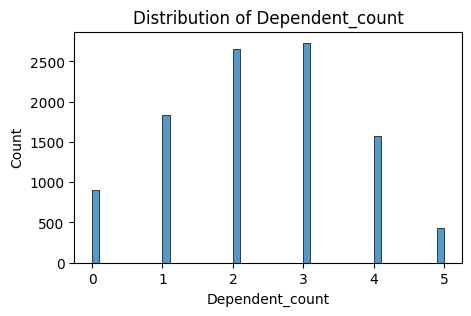

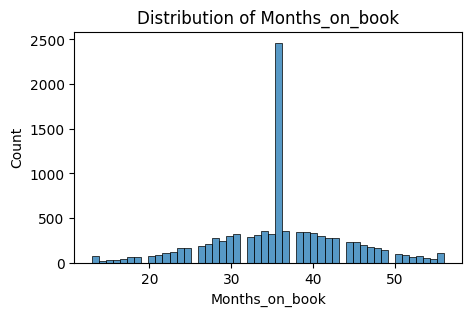

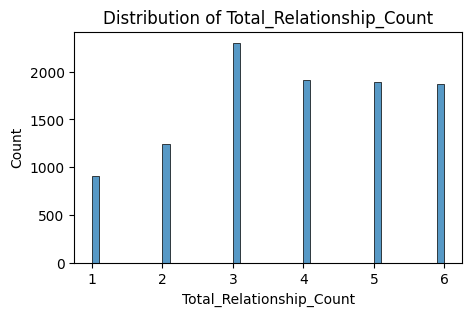

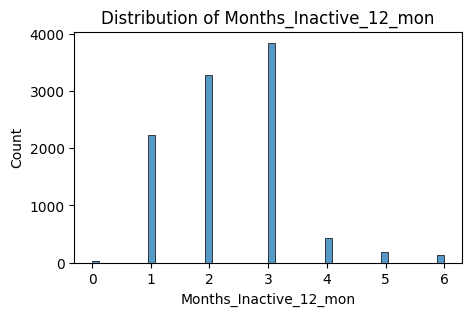

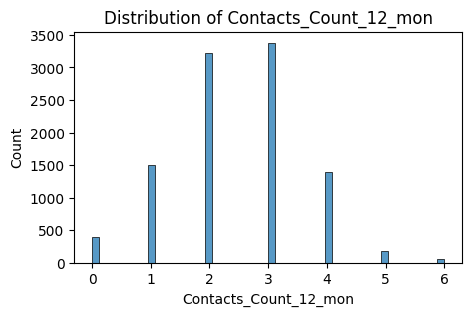

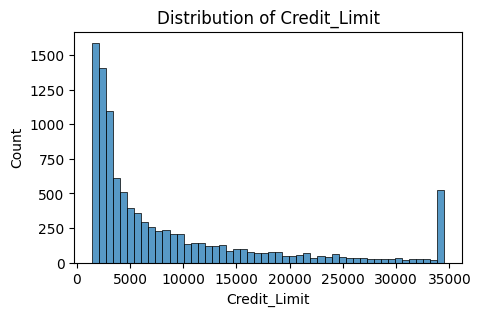

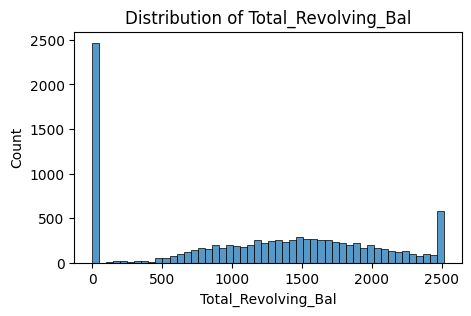

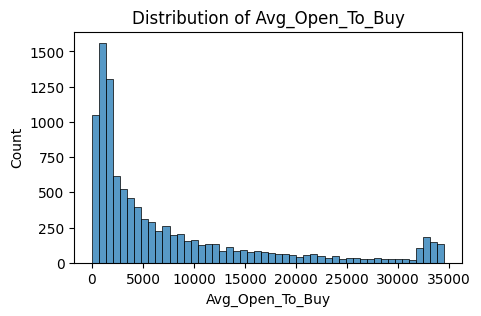

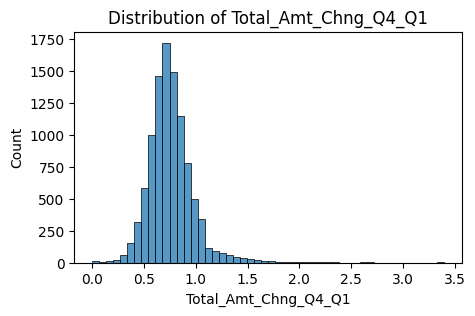

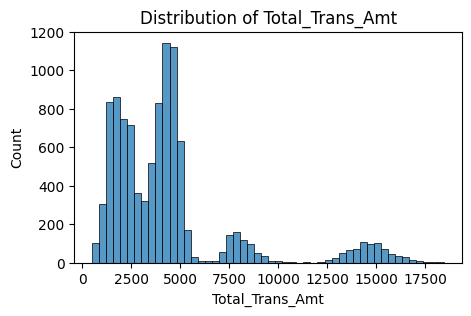

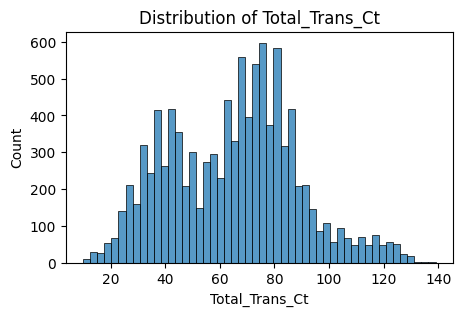

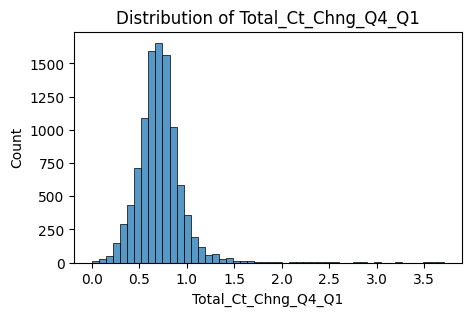

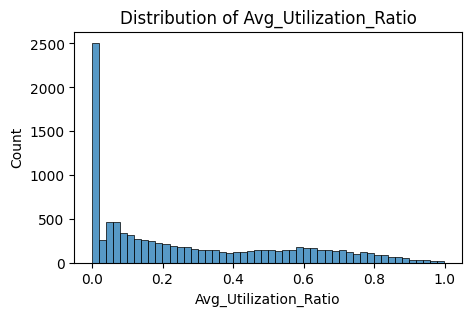

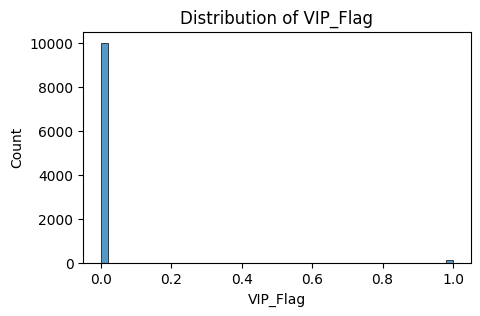

In [3]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [4]:
stats = pd.DataFrame({
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurt()
})

stats.sort_values(by="Skewness", ascending=False)

,Skewness,Kurtosis
VIP_Flag,9.814429,94.341654
Total_Ct_Chng_Q4_Q1,2.064031,15.689293
Total_Trans_Amt,2.041003,3.894023
Total_Amt_Chng_Q4_Q1,1.732063,9.993501
Credit_Limit,1.666726,1.808989
Avg_Open_To_Buy,1.661697,1.798617
Avg_Utilization_Ratio,0.718008,-0.794972
Months_Inactive_12_mon,0.633061,1.098523
Total_Trans_Ct,0.153673,-0.367163
Contacts_Count_12_mon,0.011006,0.000863


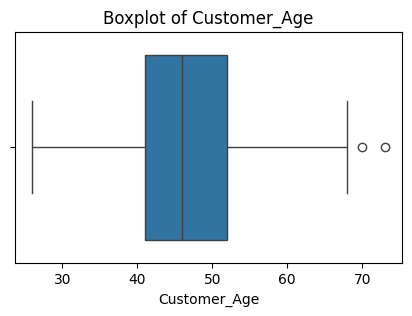

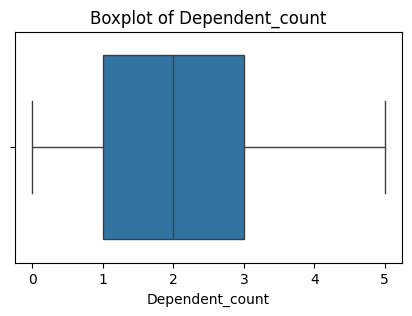

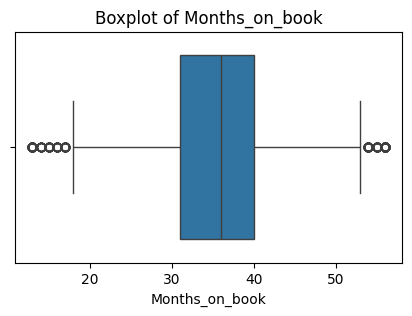

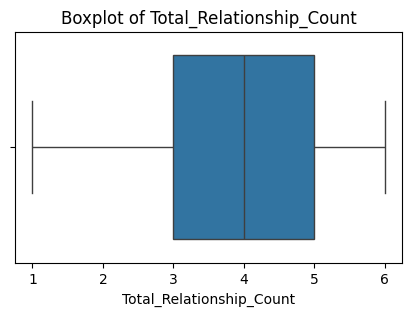

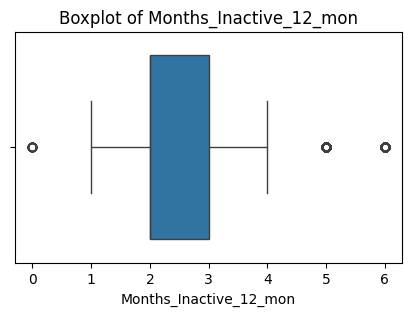

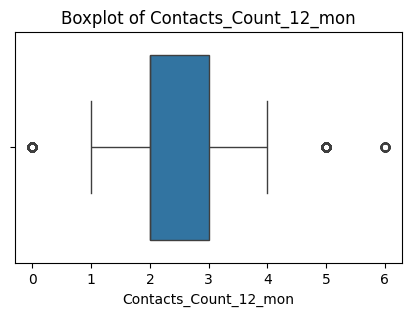

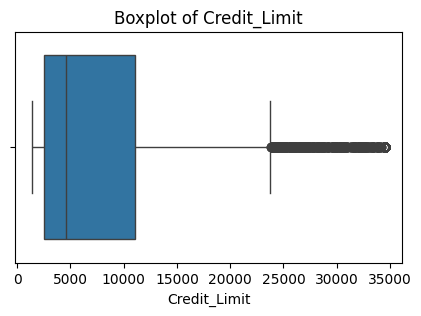

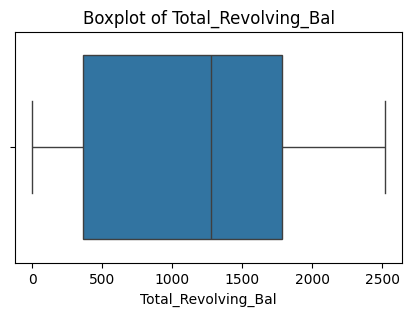

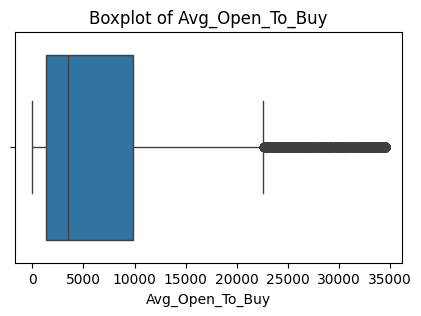

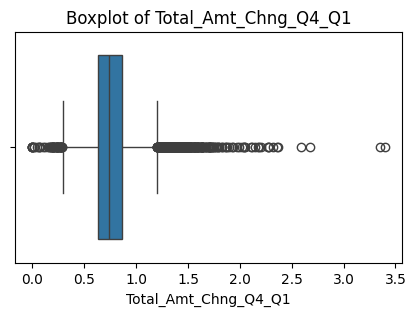

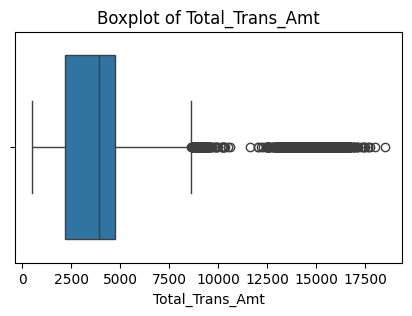

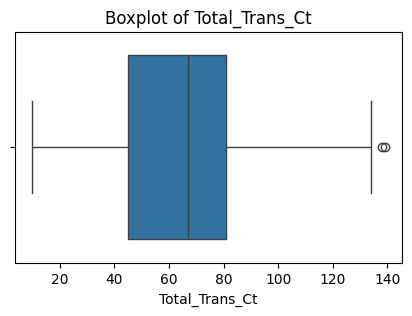

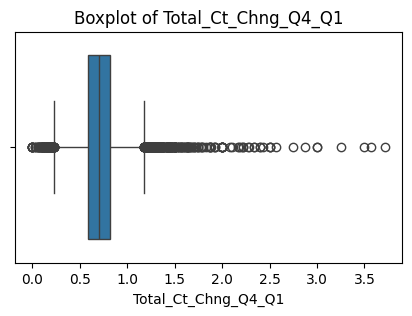

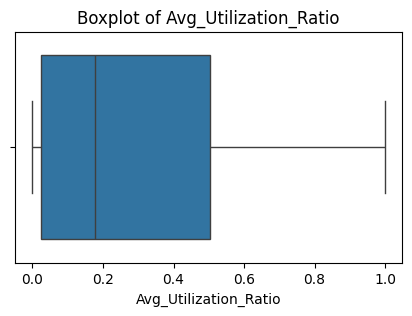

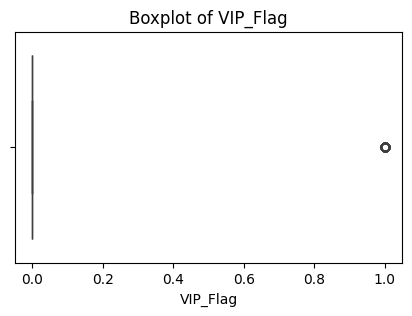

In [6]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Key Observations

- Several financial variables show right-skewed distributions
- Presence of high-value outliers (potential VIP customers)
- Certain variables exhibit heavy tails, indicating variability in spending behavior

These observations guide feature engineering and modeling decisions.